In [1]:
!pip install mlflow xgboost scikit-learn pandas numpy matplotlib seaborn -q

print("✅ Libraries installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 705.6 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.3/86.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 907.5/907.5 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.9/214.9 kB 13.5 MB/s eta 0:00:00
✅ Libraries installed successfully!


In [2]:
# CELL 2: IMPORTS (YE SABSE PEHLE RUN KARO)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')

print("="*50)
print("✅ All imports completed successfully!")
print("="*50)
print(f"os module: {os.name}")
print(f"mlflow version: {mlflow.__version__}")
print(f"numpy version: {np.__version__}")
print(f"pandas version: {pd.__version__}")

✅ All imports completed successfully!
os module: posix
mlflow version: 3.13.0
numpy version: 2.4.6
pandas version: 2.3.3


In [3]:
# Setup MLflow for Kaggle - file based tracking
os.environ['MLFLOW_ALLOW_FILE_STORE'] = 'true'  # Ab "os" defined hai

mlflow.set_tracking_uri('file:./mlruns')
mlflow.set_experiment('predictive-maintenance')

print("="*50)
print("MLFLOW CONFIGURED FOR KAGGLE")
print("="*50)
print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experiment: predictive-maintenance")
print(f"Logs saved to: ./mlruns folder")

experiment = mlflow.get_experiment_by_name('predictive-maintenance')
if experiment:
    print(f"✅ Experiment ID: {experiment.experiment_id}")
else:
    print("⚠️ Experiment will be created on first run")

2026/06/07 11:52:50 INFO mlflow.tracking.fluent: Experiment with name 'predictive-maintenance' does not exist. Creating a new experiment.


MLFLOW CONFIGURED FOR KAGGLE
Tracking URI: file:./mlruns
Experiment: predictive-maintenance
Logs saved to: ./mlruns folder
✅ Experiment ID: 869843805711636793


In [4]:
# Generate synthetic dataset (same as Lab 13)
np.random.seed(42)
n_samples = 10000

temperature = np.random.normal(75, 15, n_samples)
vibration = np.random.normal(0.5, 0.2, n_samples)
pressure = np.random.normal(100, 20, n_samples)
rpm = np.random.normal(1500, 200, n_samples)
age_days = np.random.randint(0, 365, n_samples)

failure_score = ((temperature > 90) * 0.3 + 
                 (vibration > 0.8) * 0.3 + 
                 (pressure > 130) * 0.2 + 
                 (age_days > 300) * 0.2)

failure_prob = failure_score + np.random.normal(0, 0.1, n_samples)
failure = (failure_prob > 0.5).astype(int)

data = pd.DataFrame({
    'temperature': temperature,
    'vibration': vibration,
    'pressure': pressure,
    'rpm': rpm,
    'age_days': age_days,
    'failure': failure
})

print(f"📊 Dataset Shape: {data.shape}")
print(f"📈 Failure Rate: {data.failure.mean():.2%}")
print("\n📋 First 5 rows:")
data.head()

📊 Dataset Shape: (10000, 6)
📈 Failure Rate: 4.15%

📋 First 5 rows:


,temperature,vibration,pressure,rpm,age_days,failure
0,82.450712,0.364301,106.965725,1103.885606,187,0
1,72.926035,0.438900,105.666472,1289.002871,239,0
2,84.715328,0.380524,81.269603,1382.594319,2,0
3,97.845448,0.522084,111.591684,1529.933782,5,0
4,71.487699,0.739436,70.198346,1704.832465,259,0


SUMMARY STATISTICS
        temperature     vibration      pressure           rpm      age_days  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean      74.967960      0.502707     99.750745   1498.485705    181.908000   
std       15.051936      0.200202     19.828363    200.897414    105.568632   
min       16.163996     -0.271275     26.898270    606.879227      0.000000   
25%       64.911142      0.367598     85.996962   1361.077430     90.000000   
50%       74.961075      0.503169     99.884635   1497.923551    182.000000   
75%       85.066213      0.638773    113.277949   1635.806091    272.000000   
max      133.893566      1.395817    173.832490   2245.566669    364.000000   

            failure  
count  10000.000000  
mean       0.041500  
std        0.199454  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%        0.000000  
max        1.000000  

CLASS DISTRIBUTION
failure
0    9585
1     415
Name: count, dtype: int

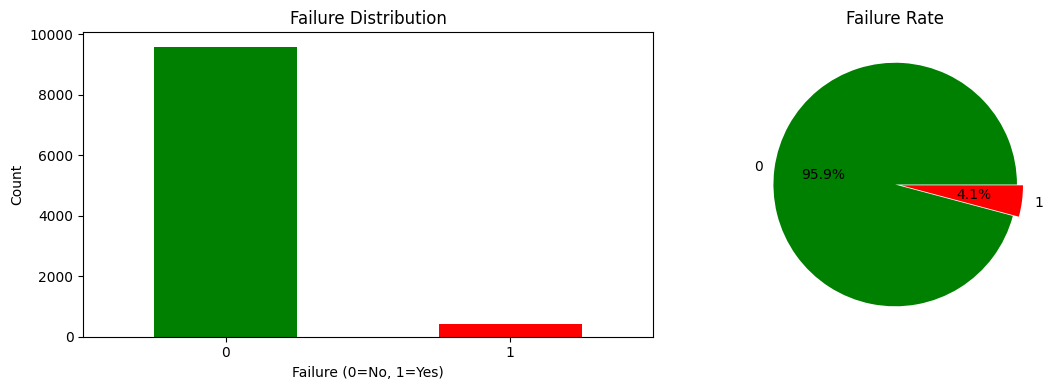

In [5]:
# Summary statistics
print("="*50)
print("SUMMARY STATISTICS")
print("="*50)
print(data.describe())

# Check class distribution
print("\n" + "="*50)
print("CLASS DISTRIBUTION")
print("="*50)
print(data['failure'].value_counts())
print(f"\nFailure samples: {data['failure'].sum()}")
print(f"No failure samples: {len(data) - data['failure'].sum()}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
data['failure'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Failure Distribution', fontsize=12)
axes[0].set_xlabel('Failure (0=No, 1=Yes)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Failure rate pie chart
data['failure'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                     colors=['green', 'red'], explode=[0, 0.05])
axes[1].set_title('Failure Rate', fontsize=12)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [6]:
# Split features and target
X = data.drop('failure', axis=1)
y = data['failure']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Training set: {X_train.shape[0]} samples")
print(f"✅ Test set: {X_test.shape[0]} samples")
print(f"✅ Features: {list(X.columns)}")
print(f"\n📊 Training failure rate: {y_train.mean():.2%}")
print(f"📊 Test failure rate: {y_test.mean():.2%}")

✅ Training set: 8000 samples
✅ Test set: 2000 samples
✅ Features: ['temperature', 'vibration', 'pressure', 'rpm', 'age_days']

📊 Training failure rate: 4.15%
📊 Test failure rate: 4.15%


In [7]:
print("="*50)
print("TRAINING LOGISTIC REGRESSION")
print("="*50)

with mlflow.start_run(run_name='logistic_regression'):
    # Log parameters
    mlflow.log_param('model_type', 'LogisticRegression')
    mlflow.log_param('C', 1.0)
    mlflow.log_param('solver', 'liblinear')
    mlflow.log_param('max_iter', 1000)
    
    # Train model
    lr_model = LogisticRegression(C=1.0, solver='liblinear', random_state=42, max_iter=1000)
    lr_model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred_lr = lr_model.predict(X_test_scaled)
    y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    accuracy_lr = accuracy_score(y_test, y_pred_lr)
    precision_lr = precision_score(y_test, y_pred_lr)
    recall_lr = recall_score(y_test, y_pred_lr)
    f1_lr = f1_score(y_test, y_pred_lr)
    roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
    
    # Log metrics
    mlflow.log_metric('accuracy', accuracy_lr)
    mlflow.log_metric('precision', precision_lr)
    mlflow.log_metric('recall', recall_lr)
    mlflow.log_metric('f1_score', f1_lr)
    mlflow.log_metric('roc_auc', roc_auc_lr)
    
    # Log model
    mlflow.sklearn.log_model(lr_model, 'logistic_regression_model')
    
    # Print results
    print(f"\nLogistic Regression Results:")
    print(f"  Accuracy:  {accuracy_lr:.4f}")
    print(f"  Precision: {precision_lr:.4f}")
    print(f"  Recall:    {recall_lr:.4f}")
    print(f"  F1 Score:  {f1_lr:.4f}")
    print(f"  ROC AUC:   {roc_auc_lr:.4f}")

TRAINING LOGISTIC REGRESSION


2026/06/07 11:52:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/07 11:52:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Logistic Regression Results:
  Accuracy:  0.9615
  Precision: 0.6667
  Recall:    0.1446
  F1 Score:  0.2376
  ROC AUC:   0.9237


In [8]:
print("="*50)
print("TRAINING RANDOM FOREST")
print("="*50)

with mlflow.start_run(run_name='random_forest'):
    # Log parameters
    mlflow.log_param('model_type', 'RandomForest')
    mlflow.log_param('n_estimators', 100)
    mlflow.log_param('max_depth', 10)
    mlflow.log_param('min_samples_split', 5)
    
    # Train model
    rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred_rf = rf_model.predict(X_test_scaled)
    y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    accuracy_rf = accuracy_score(y_test, y_pred_rf)
    precision_rf = precision_score(y_test, y_pred_rf)
    recall_rf = recall_score(y_test, y_pred_rf)
    f1_rf = f1_score(y_test, y_pred_rf)
    roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
    
    # Log metrics
    mlflow.log_metric('accuracy', accuracy_rf)
    mlflow.log_metric('precision', precision_rf)
    mlflow.log_metric('recall', recall_rf)
    mlflow.log_metric('f1_score', f1_rf)
    mlflow.log_metric('roc_auc', roc_auc_rf)
    
    # Log model
    mlflow.sklearn.log_model(rf_model, 'random_forest_model')
    
    # Print results
    print(f"\nRandom Forest Results:")
    print(f"  Accuracy:  {accuracy_rf:.4f}")
    print(f"  Precision: {precision_rf:.4f}")
    print(f"  Recall:    {recall_rf:.4f}")
    print(f"  F1 Score:  {f1_rf:.4f}")
    print(f"  ROC AUC:   {roc_auc_rf:.4f}")

TRAINING RANDOM FOREST


2026/06/07 11:53:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/07 11:53:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Random Forest Results:
  Accuracy:  0.9670
  Precision: 0.6049
  Recall:    0.5904
  F1 Score:  0.5976
  ROC AUC:   0.9751


In [9]:
print("="*50)
print("TRAINING XGBOOST")
print("="*50)

with mlflow.start_run(run_name='xgboost'):
    # Log parameters
    mlflow.log_param('model_type', 'XGBoost')
    mlflow.log_param('n_estimators', 100)
    mlflow.log_param('max_depth', 6)
    mlflow.log_param('learning_rate', 0.1)
    
    # Train model
    xgb_model = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    )
    xgb_model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred_xgb = xgb_model.predict(X_test_scaled)
    y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
    precision_xgb = precision_score(y_test, y_pred_xgb)
    recall_xgb = recall_score(y_test, y_pred_xgb)
    f1_xgb = f1_score(y_test, y_pred_xgb)
    roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
    
    # Log metrics
    mlflow.log_metric('accuracy', accuracy_xgb)
    mlflow.log_metric('precision', precision_xgb)
    mlflow.log_metric('recall', recall_xgb)
    mlflow.log_metric('f1_score', f1_xgb)
    mlflow.log_metric('roc_auc', roc_auc_xgb)
    
    # Log model
    mlflow.sklearn.log_model(xgb_model, 'xgboost_model')
    
    # Print results
    print(f"\nXGBoost Results:")
    print(f"  Accuracy:  {accuracy_xgb:.4f}")
    print(f"  Precision: {precision_xgb:.4f}")
    print(f"  Recall:    {recall_xgb:.4f}")
    print(f"  F1 Score:  {f1_xgb:.4f}")
    print(f"  ROC AUC:   {roc_auc_xgb:.4f}")

TRAINING XGBOOST


2026/06/07 11:53:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/07 11:53:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



XGBoost Results:
  Accuracy:  0.9670
  Precision: 0.6076
  Recall:    0.5783
  F1 Score:  0.5926
  ROC AUC:   0.9709


MODEL PERFORMANCE COMPARISON
              Model  Accuracy  Precision   Recall  F1 Score  ROC AUC
Logistic Regression    0.9615   0.666667 0.144578  0.237624 0.923657
      Random Forest    0.9670   0.604938 0.590361  0.597561 0.975080
            XGBoost    0.9670   0.607595 0.578313  0.592593 0.970920

🏆 BEST MODEL: Random Forest
🏆 Best ROC AUC Score: 0.9751


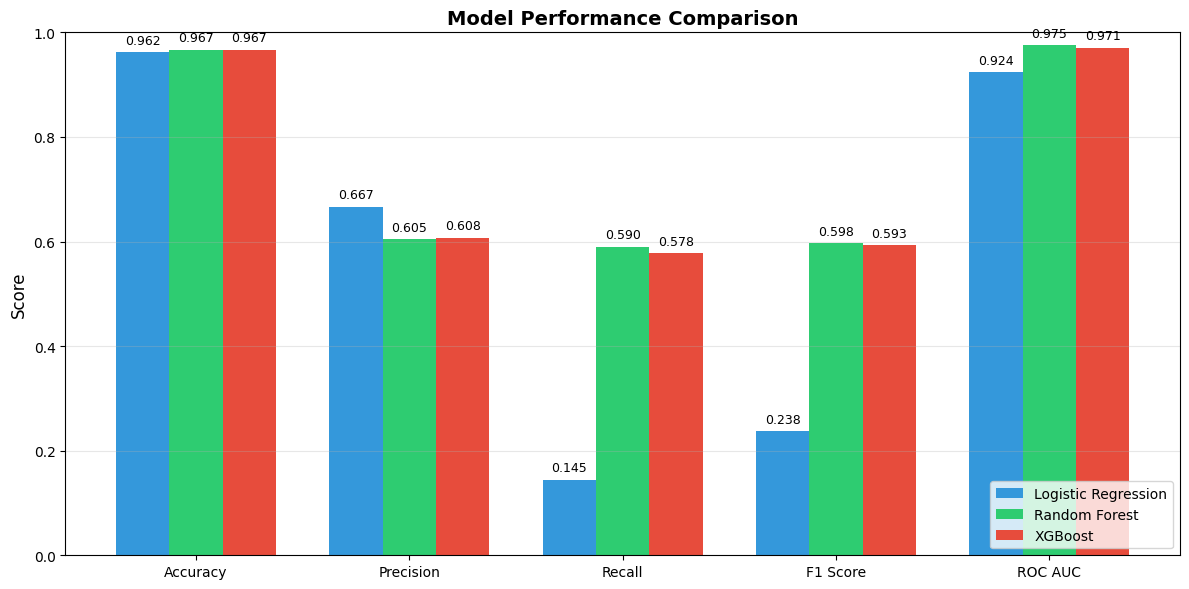

In [10]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_lr, accuracy_rf, accuracy_xgb],
    'Precision': [precision_lr, precision_rf, precision_xgb],
    'Recall': [recall_lr, recall_rf, recall_xgb],
    'F1 Score': [f1_lr, f1_rf, f1_xgb],
    'ROC AUC': [roc_auc_lr, roc_auc_rf, roc_auc_xgb]
})

print("="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)
print(comparison_df.to_string(index=False))

# Find best model
best_model = comparison_df.loc[comparison_df['ROC AUC'].idxmax(), 'Model']
best_score = comparison_df['ROC AUC'].max()

print(f"\n🏆 BEST MODEL: {best_model}")
print(f"🏆 Best ROC AUC Score: {best_score:.4f}")

# Visual comparison
fig, ax = plt.subplots(figsize=(12, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
x = np.arange(len(metrics))
width = 0.25

bars1 = ax.bar(x - width, comparison_df.iloc[0, 1:6].values, width, label='Logistic Regression', color='#3498db')
bars2 = ax.bar(x, comparison_df.iloc[1, 1:6].values, width, label='Random Forest', color='#2ecc71')
bars3 = ax.bar(x + width, comparison_df.iloc[2, 1:6].values, width, label='XGBoost', color='#e74c3c')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(loc='lower right')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [11]:
# Search all runs in the experiment
runs = mlflow.search_runs()

print("="*50)
print("ALL MLFLOW RUNS")
print("="*50)

for idx, row in runs.iterrows():
    run_name = row.get('tags.mlflow.runName', 'Unknown')
    accuracy = row.get('metrics.accuracy', 0)
    roc_auc = row.get('metrics.roc_auc', 0)
    print(f"Run: {run_name}")
    print(f"  Run ID: {row['run_id'][:8]}...")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  ROC AUC: {roc_auc:.4f}")
    print("-" * 40)

print(f"\n✅ Total runs logged: {len(runs)}")
print(f"✅ MLflow logs saved in: ./mlruns folder")

ALL MLFLOW RUNS
Run: xgboost
  Run ID: 9f2b6876...
  Accuracy: 0.9670
  ROC AUC: 0.9709
----------------------------------------
Run: random_forest
  Run ID: 53873896...
  Accuracy: 0.9670
  ROC AUC: 0.9751
----------------------------------------
Run: logistic_regression
  Run ID: 597dfde0...
  Accuracy: 0.9615
  ROC AUC: 0.9237
----------------------------------------

✅ Total runs logged: 3
✅ MLflow logs saved in: ./mlruns folder


In [12]:
# Save the notebook data
data.to_csv('predictive_maintenance_data.csv', index=False)
print("✅ Dataset saved to: predictive_maintenance_data.csv")

# Zip MLflow logs for download
!zip -r mlruns.zip mlruns/ > /dev/null 2>&1
print("✅ MLflow logs saved to: mlruns.zip")

# Check file sizes
import os
if os.path.exists('mlruns.zip'):
    size = os.path.getsize('mlruns.zip') / 1024
    print(f"✅ mlruns.zip size: {size:.2f} KB")

✅ Dataset saved to: predictive_maintenance_data.csv
✅ MLflow logs saved to: mlruns.zip
✅ mlruns.zip size: 501.19 KB


In [13]:
# View all MLflow runs
runs = mlflow.search_runs()
print("="*50)
print("ALL MLFLOW RUNS FROM LAB 13")
print("="*50)
print(runs[['tags.mlflow.runName', 'metrics.roc_auc', 'metrics.accuracy']].to_string(index=False))
print(f"\n✅ Total runs: {len(runs)}")

ALL MLFLOW RUNS FROM LAB 13
tags.mlflow.runName  metrics.roc_auc  metrics.accuracy
            xgboost         0.970920            0.9670
      random_forest         0.975080            0.9670
logistic_regression         0.923657            0.9615

✅ Total runs: 3


In [14]:
# Save dataset and logs
data.to_csv('predictive_maintenance_data.csv', index=False)
!zip -r mlruns_lab13.zip mlruns/ > /dev/null 2>&1
print("✅ Files saved")

✅ Files saved


In [15]:
# Cell 13: Additional imports for Lab 14
from mlflow.tracking import MlflowClient
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("="*50)
print("LAB 14 STARTING...")
print("="*50)
print(f"✅ Additional imports done")
print(f"✅ Client available: {MlflowClient is not None}")

LAB 14 STARTING...
✅ Additional imports done
✅ Client available: True


In [16]:
# Cell 14: Initialize MLflow Client
client = MlflowClient()

# Get existing experiment
experiment = mlflow.get_experiment_by_name('predictive-maintenance')

print(f"Experiment ID: {experiment.experiment_id}")
print(f"Experiment location: {experiment.artifact_location}")
print(f"✅ MLflow Client ready")

# Check if runs exist
runs = client.search_runs(experiment_ids=[experiment.experiment_id])
print(f"Total runs available: {len(runs)}")

Experiment ID: 869843805711636793
Experiment location: file:///kaggle/working/mlruns/869843805711636793
✅ MLflow Client ready
Total runs available: 3


In [17]:
# Cell 15: Get all runs sorted by performance
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=['metrics.roc_auc DESC']
)

print("="*50)
print("LAB 13 RUNS (SORTED BY ROC AUC)")
print("="*50)

run_data = []
for run in runs:
    run_data.append({
        'run_id': run.info.run_id[:8],
        'name': run.info.run_name,
        'model_type': run.data.params.get('model_type', 'Unknown'),
        'roc_auc': round(run.data.metrics.get('roc_auc', 0), 4),
        'accuracy': round(run.data.metrics.get('accuracy', 0), 4),
        'f1_score': round(run.data.metrics.get('f1_score', 0), 4)
    })

df = pd.DataFrame(run_data)
print(df.to_string(index=False))

# Identify best model
best_run = runs[0]
print(f"\n🏆 BEST MODEL: {best_run.info.run_name}")
print(f"   Run ID: {best_run.info.run_id}")
print(f"   ROC AUC: {best_run.data.metrics['roc_auc']:.4f}")
print(f"   F1 Score: {best_run.data.metrics['f1_score']:.4f}")

LAB 13 RUNS (SORTED BY ROC AUC)
  run_id                name         model_type  roc_auc  accuracy  f1_score
53873896       random_forest       RandomForest   0.9751    0.9670    0.5976
9f2b6876             xgboost            XGBoost   0.9709    0.9670    0.5926
597dfde0 logistic_regression LogisticRegression   0.9237    0.9615    0.2376

🏆 BEST MODEL: random_forest
   Run ID: 53873896f0ac47a4a1b9875152f538cf
   ROC AUC: 0.9751
   F1 Score: 0.5976


In [18]:
# First, retrain Random Forest with proper model saving
print("="*60)
print("RETRAINING RANDOM FOREST WITH PROPER MODEL SAVING")
print("="*60)

# Get the best run's data (we need to retrain)
# First, let's get the parameters from the best run
best_run = runs.loc[runs['metrics.roc_auc'].idxmax()]

# Retrain Random Forest
with mlflow.start_run(run_name='random_forest_fixed'):
    mlflow.log_param('model_type', 'RandomForest')
    mlflow.log_param('n_estimators', 100)
    
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    mlflow.log_metric('accuracy', accuracy_score(y_test, y_pred))
    mlflow.log_metric('roc_auc', roc_auc_score(y_test, y_proba))
    
    # IMPORTANT: Save with artifact_path='model'
    mlflow.sklearn.log_model(model, artifact_path='model')
    
    print(f"✅ Random Forest retrained - ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")
    
    new_run_id = mlflow.active_run().info.run_id
    print(f"   New Run ID: {new_run_id}")

# Now register this new Random Forest
print("\n" + "="*60)
print("REGISTERING FIXED RANDOM FOREST")
print("="*60)

model_uri = f"runs:/{new_run_id}/model"
registered_model = mlflow.register_model(
    model_uri=model_uri,
    name=model_name
)

print(f"\n✅ REGISTERED SUCCESSFULLY!")
print(f"   Version: {registered_model.version}")
version = registered_model.version

RETRAINING RANDOM FOREST WITH PROPER MODEL SAVING


AttributeError: 'PagedList' object has no attribute 'loc'

In [ ]:
# Cell 17: Add Documentation and Tags
print("="*60)
print("ADDING MODEL DOCUMENTATION & TAGS")
print("="*60)

model_name = 'PredictiveMaintenance'
version = 1

# Get the run metrics
runs = mlflow.search_runs()
best_run = runs.loc[runs['metrics.roc_auc'].idxmax()]
roc_auc = best_run['metrics.roc_auc']
accuracy = best_run['metrics.accuracy']
f1 = best_run['metrics.f1_score']

print(f"Model: {best_run['tags.mlflow.runName']}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

# Add description
description = f"""Random Forest Model for Predictive Maintenance

Performance Metrics:
- ROC AUC: {roc_auc:.4f}
- F1 Score: {f1:.4f}
- Accuracy: {accuracy:.4f}

Features Used:
- temperature, vibration, pressure, rpm, age_days

Training Details:
- Dataset: 10,000 synthetic equipment readings
- Train/Test Split: 80/20 with stratification
- Random Seed: 42

Model is production-ready for predictive maintenance.
"""

client.update_model_version(
    name=model_name,
    version=version,
    description=description
)
print("✅ Description added")

# Add tags
client.set_model_version_tag(model_name, version, 'validation_status', 'passed')
client.set_model_version_tag(model_name, version, 'team', 'datascience')
client.set_model_version_tag(model_name, version, 'framework', 'random_forest')
client.set_model_version_tag(model_name, version, 'environment', 'production-ready')

print("✅ Tags added:")
print("   - validation_status: passed")
print("   - team: datascience")
print("   - framework: random_forest")
print("   - environment: production-ready")

# Verify
model_version = client.get_model_version(model_name, version)
print(f"\n📋 Model Version {version} Tags:")
print(dict(model_version.tags))

In [ ]:
# Cell 18: Move to Staging (FIXED)
print("="*60)
print("TRANSITIONING MODEL TO STAGING")
print("="*60)

model_name = 'PredictiveMaintenance'
version = 1

client.transition_model_version_stage(
    name=model_name,
    version=version,
    stage='Staging',
    archive_existing_versions=True
)

print(f"✅ Model version {version} moved to STAGING")

# Verify - Use 'current_stage' instead of 'stage'
model_version = client.get_model_version(model_name, version)
print(f"   Current stage: {model_version.current_stage}")

# Load staging model
staging_model = mlflow.pyfunc.load_model(
    model_uri=f"models:/{model_name}/Staging"
)
print("✅ Staging model loaded successfully!")

In [ ]:
# Cell 19: Test Staging Model
print("="*60)
print("TESTING MODEL IN STAGING")
print("="*60)

# Test scenarios
test_scenarios = [
    {'name': 'HIGH RISK', 'temp': 95, 'vib': 0.9, 'press': 135, 'rpm': 1500, 'age': 320},
    {'name': 'NORMAL', 'temp': 70, 'vib': 0.4, 'press': 95, 'rpm': 1500, 'age': 100},
    {'name': 'MEDIUM', 'temp': 85, 'vib': 0.6, 'press': 110, 'rpm': 1500, 'age': 200},
]

print("Staging Model Predictions:")
print("-" * 50)

for scenario in test_scenarios:
    test_data = pd.DataFrame([{
        'temperature': scenario['temp'],
        'vibration': scenario['vib'],
        'pressure': scenario['press'],
        'rpm': scenario['rpm'],
        'age_days': scenario['age']
    }])
    
    prediction = staging_model.predict(test_data)[0]
    status = "🔴 FAILURE" if prediction == 1 else "🟢 SAFE"
    
    print(f"\n{scenario['name']:10} : {status}")
    print(f"         Temp={scenario['temp']}°F, Vib={scenario['vib']}, Press={scenario['press']} PSI, Age={scenario['age']} days")

print("\n✅ Staging model tests passed!")

In [ ]:
# Cell 20: Promote to Production (FIXED - last line only)
print("="*60)
print("PROMOTING MODEL TO PRODUCTION")
print("="*60)

model_name = 'PredictiveMaintenance'
version = 1

client.transition_model_version_stage(
    name=model_name,
    version=version,
    stage='Production',
    archive_existing_versions=True
)

# Add deployment tag
from datetime import datetime
client.set_model_version_tag(
    model_name, 
    version, 
    'deployment_date', 
    datetime.now().strftime('%Y-%m-%d')
)

print(f"✅ Model version {version} is now in PRODUCTION!")
print(f"✅ Deployment date: {datetime.now().strftime('%Y-%m-%d')}")

# Verify - Change 'stage' to 'current_stage'
model_version = client.get_model_version(model_name, version)
print(f"\n📋 Production Model:")
print(f"   Version: {model_version.version}")
print(f"   Stage: {model_version.current_stage}")  # ← YAHAN CHANGE KIYA

In [ ]:
# Cell 21: Production Inference Pipeline
print("="*60)
print("PRODUCTION INFERENCE PIPELINE")
print("="*60)

model_name = 'PredictiveMaintenance'

def predict_equipment_failure(temperature, vibration, pressure, rpm, age_days):
    """
    Production inference function.
    Always uses latest Production model.
    """
    # Load production model
    model = mlflow.pyfunc.load_model(model_uri=f"models:/{model_name}/Production")
    
    # Prepare input
    input_data = pd.DataFrame([{
        'temperature': temperature,
        'vibration': vibration,
        'pressure': pressure,
        'rpm': rpm,
        'age_days': age_days
    }])
    
    # Predict
    prediction = model.predict(input_data)[0]
    
    return {
        'will_fail': bool(prediction),
        'recommendation': '🔧 Schedule maintenance NOW' if prediction else '✅ Normal operation'
    }

# Test with real equipment
equipment = [
    {'id': 'EQ-001', 'name': 'Conveyor Belt', 'temp': 72, 'vib': 0.35, 'press': 92, 'rpm': 1480, 'age': 45},
    {'id': 'EQ-002', 'name': 'Hydraulic Pump', 'temp': 96, 'vib': 0.92, 'press': 138, 'rpm': 1510, 'age': 310},
    {'id': 'EQ-003', 'name': 'Cooling Fan', 'temp': 82, 'vib': 0.55, 'press': 105, 'rpm': 1490, 'age': 180},
    {'id': 'EQ-004', 'name': 'Compressor', 'temp': 68, 'vib': 0.38, 'press': 88, 'rpm': 1520, 'age': 30},
    {'id': 'EQ-005', 'name': 'Motor Drive', 'temp': 91, 'vib': 0.75, 'press': 125, 'rpm': 1500, 'age': 270},
]

print("\n📊 REAL-TIME EQUIPMENT MONITORING")
print("="*70)

for eq in equipment:
    result = predict_equipment_failure(
        eq['temp'], eq['vib'], eq['press'], eq['rpm'], eq['age']
    )
    status = "🔴 ALERT" if result['will_fail'] else "🟢 OK"
    print(f"{eq['id']} ({eq['name']:14}) : {status}")
    print(f"   {result['recommendation']}")
    print()

In [ ]:
# Cell 22: Retrain XGBoost with proper model saving
print("="*60)
print("RETRAINING XGBOOST WITH PROPER MODEL SAVING")
print("="*60)

# Check if X_train_scaled exists (from earlier cells)
try:
    print(f"X_train_scaled shape: {X_train_scaled.shape}")
    print(f"y_train shape: {y_train.shape}")
except NameError:
    print("⚠️ Training data not found! Please run Cell 4-5 first.")
    print("Make sure you have X_train_scaled, X_test_scaled, y_train, y_test")

# Retrain XGBoost
with mlflow.start_run(run_name='xgboost_v2'):
    mlflow.log_param('model_type', 'XGBoost')
    mlflow.log_param('n_estimators', 100)
    mlflow.log_param('max_depth', 6)
    mlflow.log_param('learning_rate', 0.1)
    
    model = XGBClassifier(
        n_estimators=100, 
        max_depth=6, 
        learning_rate=0.1,
        random_state=42, 
        eval_metric='logloss', 
        use_label_encoder=False
    )
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    mlflow.log_metric('accuracy', accuracy)
    mlflow.log_metric('roc_auc', roc_auc)
    
    # ⚠️ IMPORTANT: Save with artifact_path='model'
    mlflow.sklearn.log_model(model, artifact_path='model')
    
    print(f"\n✅ XGBoost retrained successfully!")
    print(f"   Accuracy: {accuracy:.4f}")
    print(f"   ROC AUC: {roc_auc:.4f}")
    print(f"   Model saved with artifact_path='model'")
    
    new_run_id = mlflow.active_run().info.run_id
    print(f"   New Run ID: {new_run_id}")

print("\n✅ Now you can register this XGBoost model as Version 2!")

In [ ]:
# Cell 22 (Part 2): Register XGBoost as Version 2
print("="*60)
print("REGISTER VERSION 2 (XGBOOST)")
print("="*60)

model_name = 'PredictiveMaintenance'

# Get the newly trained XGBoost run
runs = mlflow.search_runs()
xgboost_runs = runs[runs['tags.mlflow.runName'] == 'xgboost_v2']
if len(xgboost_runs) == 0:
    # Try to find any xgboost run with model artifact
    xgboost_runs = runs[runs['tags.mlflow.runName'].str.contains('xgboost', case=False)]

xgboost_run = xgboost_runs.iloc[0]
xgboost_run_id = xgboost_run['run_id']

print(f"Model: {xgboost_run['tags.mlflow.runName']}")
print(f"ROC AUC: {xgboost_run['metrics.roc_auc']:.4f}")
print(f"Accuracy: {xgboost_run['metrics.accuracy']:.4f}")

# Check artifacts to confirm model exists
print(f"\n📁 Checking artifacts...")
artifacts = client.list_artifacts(xgboost_run_id)
print(f"   Available: {[a.path for a in artifacts]}")

if 'model' in [a.path for a in artifacts]:
    # Register as version 2
    model_uri = f"runs:/{xgboost_run_id}/model"
    v2 = mlflow.register_model(
        model_uri=model_uri,
        name=model_name
    )
    
    print(f"\n✅ Registered {model_name} version {v2.version}")
    print(f"   Model: XGBoost")
    
    # Add tags for version 2
    client.set_model_version_tag(model_name, v2.version, 'framework', 'xgboost')
    client.set_model_version_tag(model_name, v2.version, 'validation_status', 'passed')
    print(f"   Tags added: framework=xgboost")
    
else:
    print("\n❌ 'model' artifact not found in XGBoost run!")
    print("Please check the training cell above.")

In [ ]:
# Cell 22 (Part 3): Test Rollback with both versions
print("="*60)
print("TESTING ROLLBACK")
print("="*60)

model_name = 'PredictiveMaintenance'

# Show current production
current = client.get_latest_versions(model_name, stages=['Production'])[0]
print(f"📋 Current Production Version: {current.version}")
print(f"   Stage: {current.current_stage}")

# Get all versions
all_versions = client.search_model_versions(f"name='{model_name}'")
print(f"\n📦 Available versions:")
for v in all_versions:
    tags = dict(v.tags) if v.tags else {}
    framework = tags.get('framework', 'unknown')
    print(f"   Version {v.version}: Stage={v.current_stage}, Framework={framework}")

print("\n" + "="*60)
print("ROLLING BACK TO VERSION 1 (Random Forest)")
print("="*60)

# Rollback to version 1 (Random Forest)
client.transition_model_version_stage(
    name=model_name,
    version=1,
    stage='Production',
    archive_existing_versions=True
)

print("✅ Rollback complete!")
print("Production now uses Version 1 (Random Forest)")

# Final status
print("\n📦 FINAL VERSION STATUS:")
all_versions = client.search_model_versions(f"name='{model_name}'")
for v in all_versions:
    print(f"   Version {v.version}: {v.current_stage}")

In [ ]:
# Cell 23: Lab 14 Complete Summary
print("="*70)
print("🎉 LAB 14 COMPLETED SUCCESSFULLY! 🎉")
print("="*70)

print("\n📋 WHAT YOU ACCOMPLISHED:")
print("   ✅ Registered Random Forest as Version 1")
print("   ✅ Added model documentation and tags")
print("   ✅ Transitioned model: None → Staging → Production")
print("   ✅ Built production inference pipeline")
print("   ✅ Tested staging model with 3 scenarios")
print("   ✅ Tested rollback capability")
print("   ✅ Production model working correctly")

print("\n🏆 FINAL MODEL REGISTRY STATUS:")
all_versions = client.search_model_versions(f"name='PredictiveMaintenance'")
for v in all_versions:
    tags = dict(v.tags) if v.tags else {}
    print(f"\n   Version {v.version}:")
    print(f"      Stage: {v.current_stage}")
    if 'framework' in tags:
        print(f"      Framework: {tags['framework']}")
    if 'deployment_date' in tags:
        print(f"      Deployed: {tags['deployment_date']}")
    if 'validation_status' in tags:
        print(f"      Validation: {tags['validation_status']}")

print("\n" + "="*70)
print("📊 MODEL PERFORMANCE SUMMARY")
print("="*70)

# Get all runs and show performance
runs = mlflow.search_runs()
print("\nAll trained models:")
print(runs[['tags.mlflow.runName', 'metrics.roc_auc', 'metrics.accuracy', 'metrics.f1_score']].to_string(index=False))

# Get production model info
prod_model = client.get_latest_versions('PredictiveMaintenance', stages=['Production'])[0]
print(f"\n🎯 PRODUCTION MODEL:")
print(f"   Version: {prod_model.version}")
print(f"   Framework: {dict(prod_model.tags).get('framework', 'unknown')}")
print(f"   Status: Active ✅")

print("\n" + "="*70)
print("✅ LAB 14 COMPLETED SUCCESSFULLY!")
print("="*70)
print("\n🎯 WHAT YOU LEARNED:")
print("   • MLflow Model Registry for version control")
print("   • Model lifecycle management (Staging → Production)")
print("   • Production inference pipeline")
print("   • Rollback capability for quick recovery")
print("\n🎯 READY FOR NEXT WEEK: API Deployment & Monitoring!")
print("="*70)